In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\python\Machine learning\MLREVISION\Rent_Prediction_Area_Large_Dataset.xlsx")
df

,Area (sq.ft.),Monthly Rent (₹)
0,300,5612
1,325,7090
2,350,6491
3,375,8174
4,400,7894
...,...,...
108,3000,60300
109,3025,60148
110,3050,61285
111,3075,60778


In [3]:
df.head()

,Area (sq.ft.),Monthly Rent (₹)
0,300,5612
1,325,7090
2,350,6491
3,375,8174
4,400,7894


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Area (sq.ft.)     113 non-null    int64
 1   Monthly Rent (₹)  113 non-null    int64
dtypes: int64(2)
memory usage: 1.9 KB


In [5]:
df.isnull().sum()

Area (sq.ft.)       0
Monthly Rent (₹)    0
dtype: int64

In [6]:
df.describe()

,Area (sq.ft.),Monthly Rent (₹)
count,113.000000,113.000000
mean,1700.000000,34073.672566
std,819.107746,16367.173873
min,300.000000,5612.000000
25%,1000.000000,20169.000000
50%,1700.000000,34653.000000
75%,2400.000000,48559.000000
max,3100.000000,61342.000000


In [7]:
df['Monthly Rent (₹)']=df['Monthly Rent (₹)']*100000
df['Monthly Rent (₹)']

0       561200000
1       709000000
2       649100000
3       817400000
4       789400000
          ...    
108    6030000000
109    6014800000
110    6128500000
111    6077800000
112    6134200000
Name: Monthly Rent (₹), Length: 113, dtype: int64

In [8]:
df

,Area (sq.ft.),Monthly Rent (₹)
0,300,561200000
1,325,709000000
2,350,649100000
3,375,817400000
4,400,789400000
...,...,...
108,3000,6030000000
109,3025,6014800000
110,3050,6128500000
111,3075,6077800000


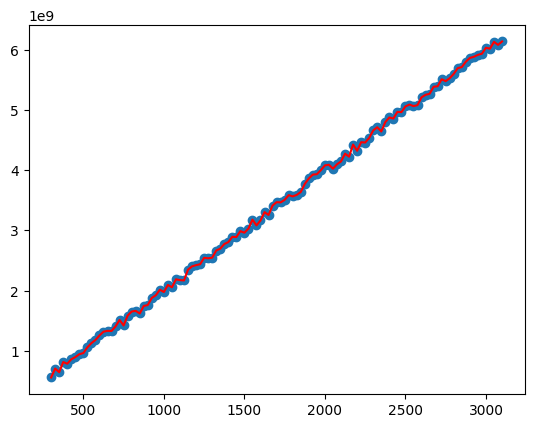

In [9]:
plt.scatter(df['Area (sq.ft.)'],df['Monthly Rent (₹)'])
plt.plot(df['Area (sq.ft.)'],df['Monthly Rent (₹)'],color='red')

In [10]:
x_mean=df['Area (sq.ft.)'].mean()
y_mean=df['Monthly Rent (₹)'].mean()

In [11]:
x_mean

np.float64(1700.0)

In [12]:
y_mean

np.float64(3407367256.637168)

In [13]:
numerator=0
denominator=0
for i,j in zip(df['Area (sq.ft.)'],df['Monthly Rent (₹)']):
    numerator+=(i-x_mean)*(j-y_mean)
    denominator+=(i-x_mean)**2


In [14]:
numerator

np.float64(150095212499999.97)

In [15]:
denominator

np.float64(75145000.0)

In [16]:
m=(numerator/denominator)
m

np.float64(1997407.8448333219)

In [17]:
c=y_mean-m*x_mean
c

np.float64(11773920.420520782)

In [18]:
# 6.	Predict the rent for: 1.	900 sq.ft. 
rent_900=m*900+c
# 2.	1100 sq.ft.
rent_1100=m*1100+c
print("Rent of 900",rent_900)
print("Rent of 1100",rent_1100)


Rent of 900 1809440980.7705104
Rent of 1100 2208922549.737175


In [19]:
df

,Area (sq.ft.),Monthly Rent (₹)
0,300,561200000
1,325,709000000
2,350,649100000
3,375,817400000
4,400,789400000
...,...,...
108,3000,6030000000
109,3025,6014800000
110,3050,6128500000
111,3075,6077800000


In [20]:
df['y_pred']=[(m*i+c) for i in df['Area (sq.ft.)']]
df['y_pred']

0      6.109963e+08
1      6.609315e+08
2      7.108667e+08
3      7.608019e+08
4      8.107371e+08
           ...     
108    6.003997e+09
109    6.053933e+09
110    6.103868e+09
111    6.153803e+09
112    6.203738e+09
Name: y_pred, Length: 113, dtype: float64

In [21]:
predicted_1000=m*1000+c
error=21000-predicted_1000
print("Error for 1000 sq.ft :",error)

Error for 1000 sq.ft : -2009160765.2538426


In [22]:
df

,Area (sq.ft.),Monthly Rent (₹),y_pred
0,300,561200000,6.109963e+08
1,325,709000000,6.609315e+08
2,350,649100000,7.108667e+08
3,375,817400000,7.608019e+08
4,400,789400000,8.107371e+08
...,...,...,...
108,3000,6030000000,6.003997e+09
109,3025,6014800000,6.053933e+09
110,3050,6128500000,6.103868e+09
111,3075,6077800000,6.153803e+09


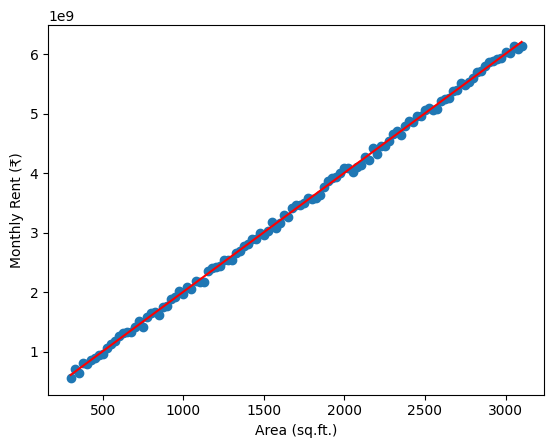

In [23]:
plt.scatter(df['Area (sq.ft.)'],df['Monthly Rent (₹)'])
plt.plot(df['Area (sq.ft.)'],df['y_pred'],color='red')
plt.xlabel("Area (sq.ft.)")
plt.ylabel("Monthly Rent (₹)")
plt.show()
